In [1]:
import scanpy as sc
print(sc.__version__)

1.11.5


C:\Users\kavya\AppData\Local\Temp\ipykernel_17452\289967954.py:2: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(sc.__version__)


In [2]:
import scanpy as sc
adata = sc.datasets.pbmc3k()
print(adata)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


In [3]:
import scanpy as sc
adata = sc.datasets.pbmc3k()
print(adata)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


In [4]:
import scanpy as sc
print("Scanpy loaded successfully")

Scanpy loaded successfully


In [5]:
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [6]:
print(adata.var_names[:10])

Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8',
       'AL627309.1', 'RP11-34P13.14', 'RP11-34P13.9', 'AP006222.2',
       'RP4-669L17.10'],
      dtype='object', name='index')


In [7]:
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [8]:
adata.obs.head()

""
index
AAACATACAACCAC-1
AAACATTGAGCTAC-1
AAACATTGATCAGC-1
AAACCGTGCTTCCG-1
AAACCGTGTATGCG-1


In [9]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=['mt'],
    percent_top=None,
    log1p=False,
    inplace=True
)
adata.obs.head()

,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt
index,,,,
AAACATACAACCAC-1,781,2421.0,73.0,3.015283
AAACATTGAGCTAC-1,1352,4903.0,186.0,3.793596
AAACATTGATCAGC-1,1131,3149.0,28.0,0.889171
AAACCGTGCTTCCG-1,960,2639.0,46.0,1.743085
AAACCGTGTATGCG-1,522,981.0,12.0,1.223242


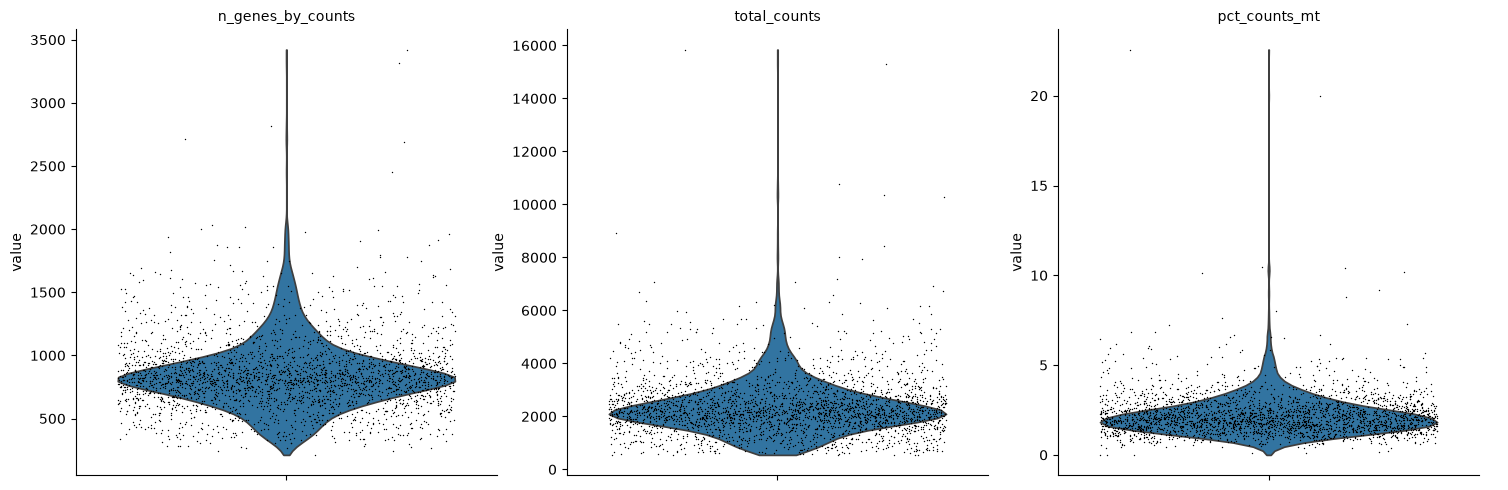

In [10]:
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
multi_panel=True
)

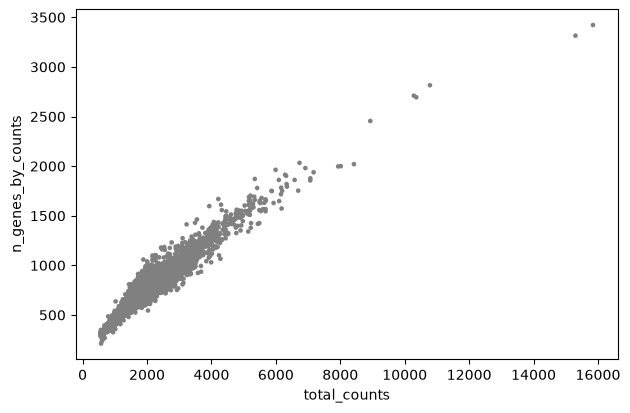

In [11]:
sc.pl.scatter(
    adata,
    x='total_counts',
    y='n_genes_by_counts'
)

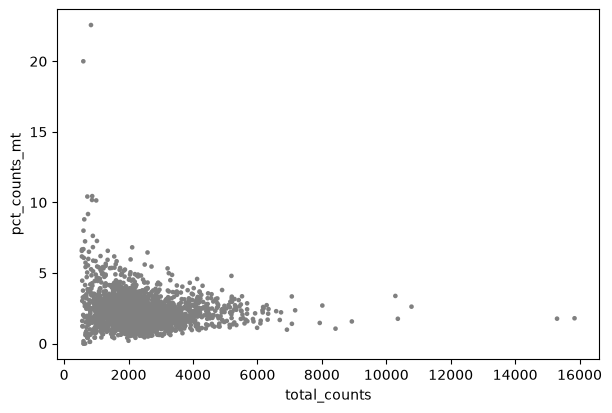

In [12]:
sc.pl.scatter(
    adata,
    x='total_counts',
    y='pct_counts_mt'
)

In [13]:
adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

adata

View of AnnData object with n_obs × n_vars = 2638 × 32738
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [14]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata

C:\Users\kavya\miniconda4\envs\scrna\Lib\site-packages\scanpy\preprocessing\_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


AnnData object with n_obs × n_vars = 2638 × 32738
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p'

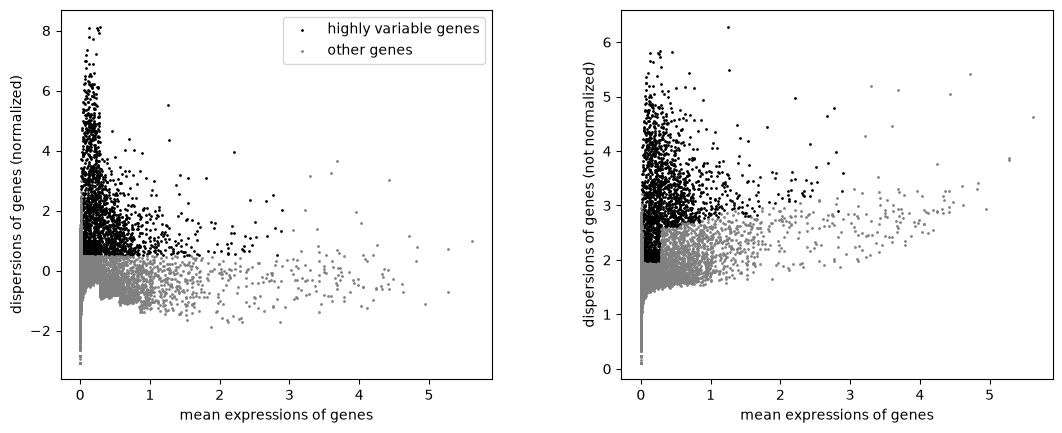

In [15]:
sc.pp.highly_variable_genes(
    adata,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5
)
sc.pl.highly_variable_genes(adata)

In [16]:
adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)
adata

C:\Users\kavya\miniconda4\envs\scrna\Lib\site-packages\scanpy\preprocessing\_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
C:\Users\kavya\miniconda4\envs\scrna\Lib\functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 2638 × 2013
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg'

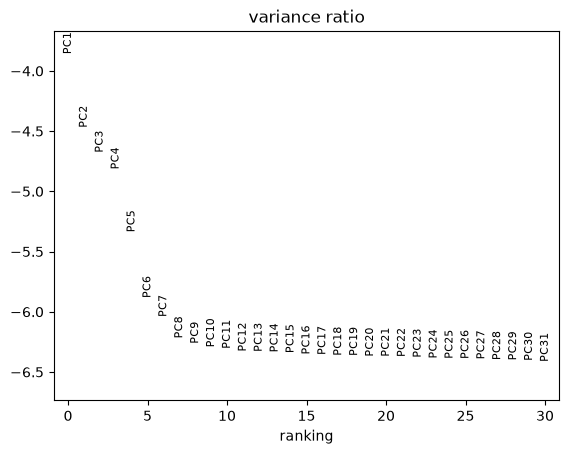

In [17]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(
    adata,
    log=True
)

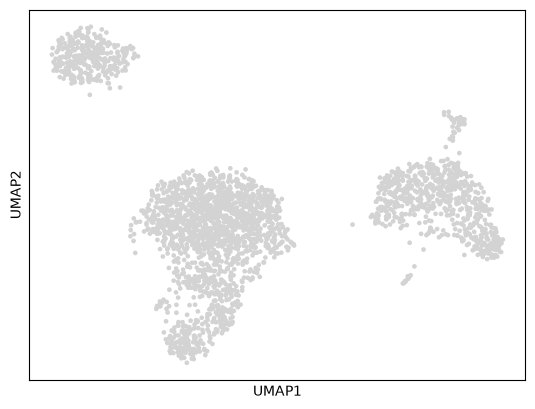

In [18]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.pl.umap(adata)

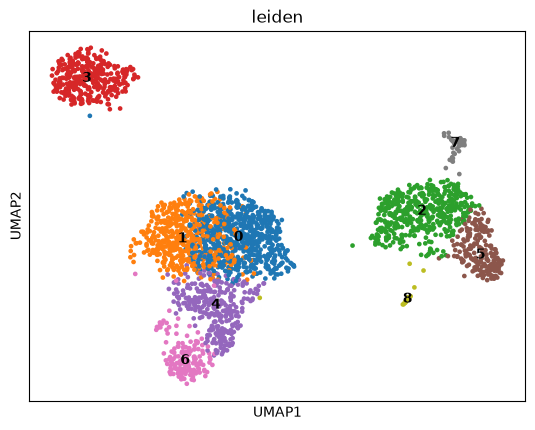

In [20]:
sc.tl.leiden(adata)
sc.pl.umap(
    adata,
    color='leiden',
    legend_loc='on data'
)

In [21]:
sc.tl.rank_genes_groups(
    adata,
    'leiden',
    method='wilcoxon'
)

C:\Users\kavya\miniconda4\envs\scrna\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\kavya\miniconda4\envs\scrna\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\kavya\miniconda4\envs\scrna\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\kavya\miniconda4\envs\scrna\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\kavya\miniconda4\envs\scrna\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Us

In [22]:
adata.uns['rank_genes_groups'].keys()

dict_keys(['params', 'names', 'scores', 'pvals', 'pvals_adj', 'logfoldchanges'])

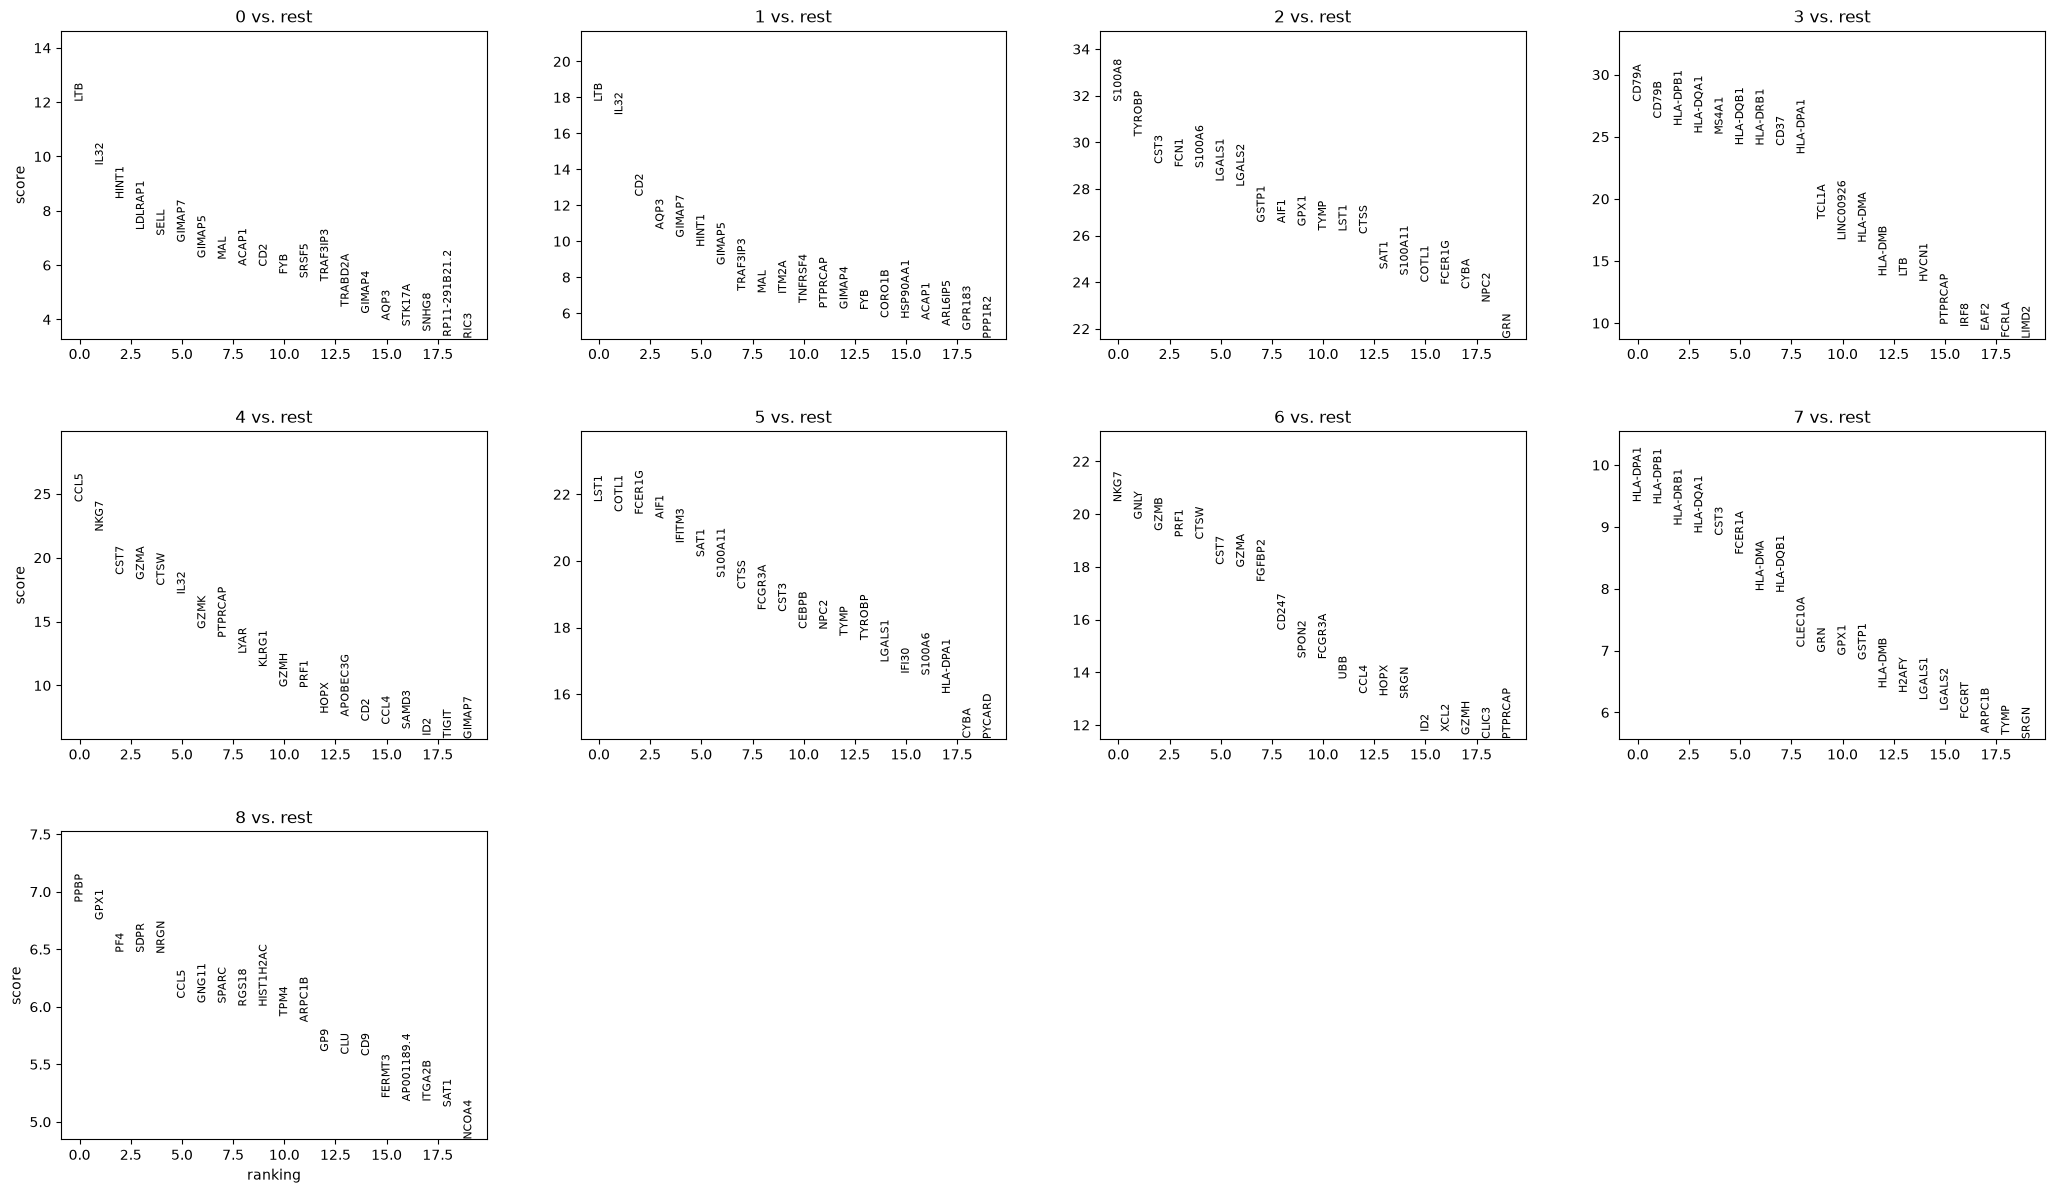

In [25]:
sc.pl.rank_genes_groups(
    adata,
    n_genes=20,
sharey=False
)

In [26]:
markers = sc.get.rank_genes_groups_df(adata, group='0')
markers.head(10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,LTB,12.014891,NaN,2.967614e-33,2.986903e-31
1,IL32,9.671119,NaN,3.999815e-22,2.439887e-20
2,HINT1,8.431211,NaN,3.421074e-17,1.765800e-15
3,LDLRAP1,7.290302,NaN,3.092600e-13,1.353349e-11
4,SELL,7.083754,NaN,1.403010e-12,5.648517e-11
5,GIMAP7,6.836166,NaN,8.134072e-12,2.823084e-10
6,GIMAP5,6.257765,NaN,3.905326e-10,1.173347e-08
7,MAL,6.199746,NaN,5.655429e-10,1.581164e-08
8,ACAP1,5.970372,NaN,2.367135e-09,6.188366e-08
9,CD2,5.946136,NaN,2.745462e-09,7.085403e-08


In [27]:
all_markers = sc.get.rank_genes_groups_df(adata, group=None)
all_markers.to_csv("../results/pbmc3k_marker_genes.csv", index=False)

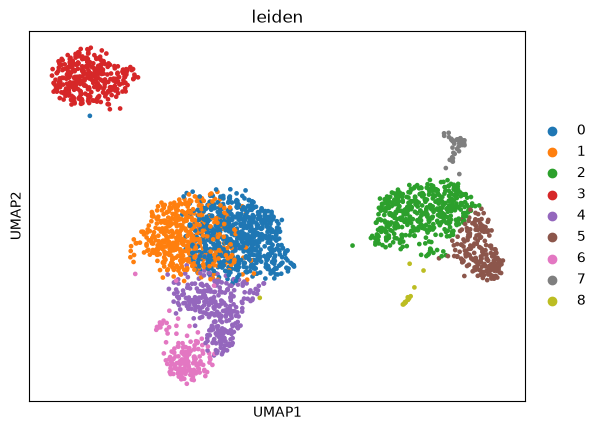

In [29]:
sc.settings.figdir = "../fighures"
sc.pl.umap(
    adata,
    color="leiden",
save="_leiden_clusters.png"
)

In [30]:
import os
print("RESULTS:")
print(os.listdir("../results"))
print("\nFIGURES:")
print(os.listdir("../figures"))

RESULTS:
['pbmc3k_marker_genes.csv']

FIGURES:
[]


In [33]:
import os
for root, dirs, files in os.walk(.."):
                                 for file in files:
    if "umap" in file.lower() or file.endswith(".png"):
        print(os.path.join(root, filemport os


IndentationError: unindent does not match any outer indentation level (<tokenize>, line 4)

In [37]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if "umap" in file.lower() or file.endswith(".png"):
            print(os.path.join(root, file))

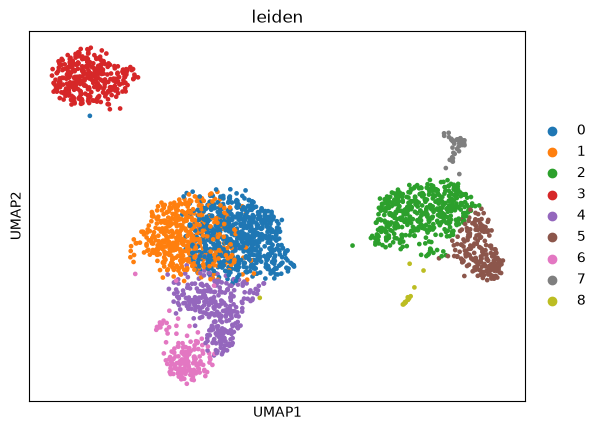

In [38]:
sc.pl.umap(
    adata,
    color="leiden",
    save="_leiden_clusters.png"
)

In [39]:
import os
os.listdir(".")

['.ipynb_checkpoints', 'data', 'pbmc3k_analysis.ipynb']

In [41]:
import os
os.listdir("../results")

['pbmc3k_marker_genes.csv']